# MNIST Dataset Exploration

This notebook helps you understand what is inside `dataset/mnist.npz` and how to use it for Phase 1 (binary) and Phase 2 (multiclass).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
data_path = '../../data/mnist.npz'

data = np.load(data_path)
print('Keys inside file:', list(data.keys()))

Keys inside file: ['x_test', 'x_train', 'y_train', 'y_test']


## 1. Basic Structure

In [3]:
x_train, y_train = data['x_train'], data['y_train']
x_test, y_test = data['x_test'], data['y_test']

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape :', x_test.shape)
print('y_test shape :', y_test.shape)
print()
print('x dtype:', x_train.dtype, '| y dtype:', y_train.dtype)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)

x dtype: uint8 | y dtype: uint8


In [4]:
# Show pixel value range before normalization
print('Pixel min/max (train):', x_train.min(), x_train.max())

# Typical normalization used in your pipeline
x_train_norm = x_train.astype(np.float32) / 255.0
print('Pixel min/max (normalized train):', x_train_norm.min(), x_train_norm.max())

Pixel min/max (train): 0 255
Pixel min/max (normalized train): 0.0 1.0


## 2. Label Distribution

In [5]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    'train_count': train_counts,
    'test_count': test_counts
}).fillna(0).astype(int)

dist_df

,train_count,test_count
0,5923,980
1,6742,1135
2,5958,1032
3,6131,1010
4,5842,982
5,5421,892
6,5918,958
7,6265,1028
8,5851,974
9,5949,1009


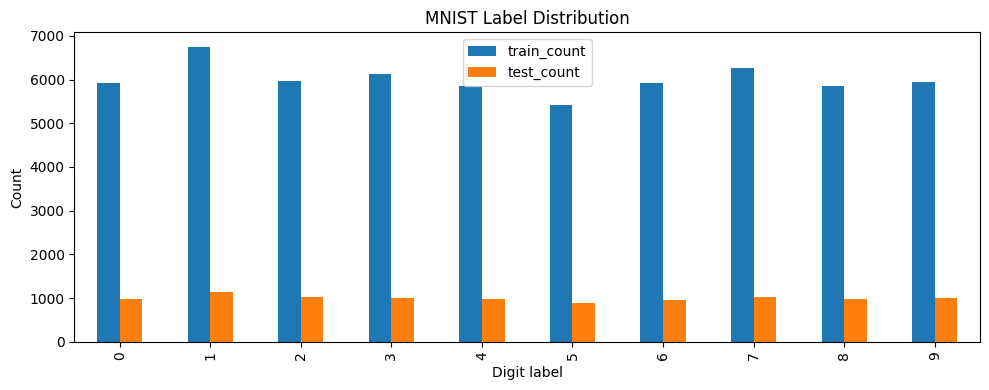

In [6]:
ax = dist_df.plot(kind='bar', figsize=(10, 4), title='MNIST Label Distribution')
ax.set_xlabel('Digit label')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Visualize Sample Images

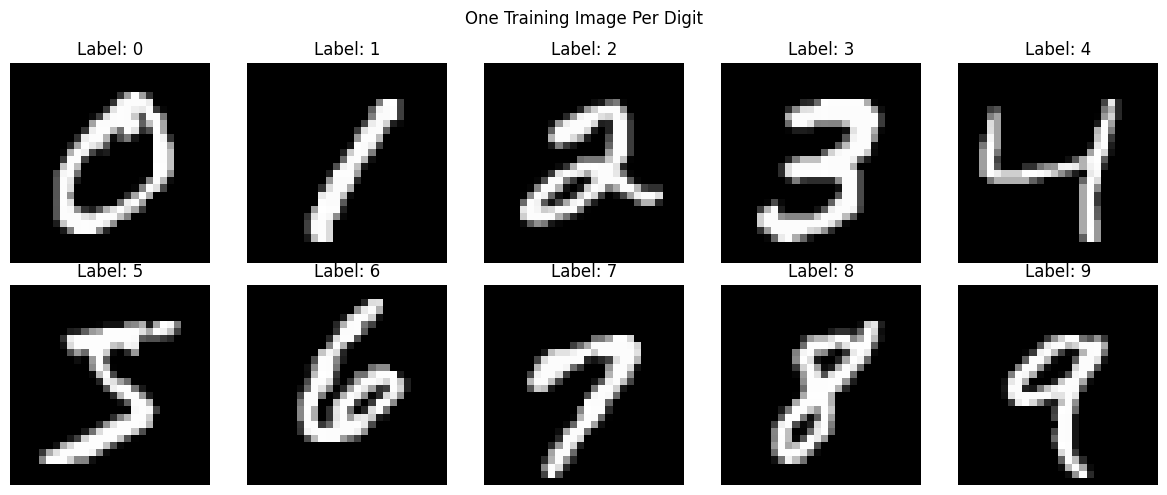

In [7]:
# Show one sample per class from training set
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[digit].imshow(x_train[idx], cmap='gray')
    axes[digit].set_title(f'Label: {digit}')
    axes[digit].axis('off')

plt.suptitle('One Training Image Per Digit')
plt.tight_layout()
plt.show()

## 4. How To Use For Phase 1 (Binary Classification)

In [8]:
# Example: class 0 vs class 1
class_a, class_b = 0, 1

x_all = np.concatenate([x_train, x_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

mask = (y_all == class_a) | (y_all == class_b)
x_bin = x_all[mask]
y_bin = y_all[mask]

print('Binary X shape:', x_bin.shape)
print('Binary y shape:', y_bin.shape)
print('Binary label counts:', dict(zip(*np.unique(y_bin, return_counts=True))))

Binary X shape: (14780, 28, 28)
Binary y shape: (14780,)
Binary label counts: {0: 6903, 1: 7877}


## 5. How To Use For Phase 2 (10-Class Classification)

In [9]:
# For multiclass, use all classes directly
x_multi = np.concatenate([x_train, x_test], axis=0)
y_multi = np.concatenate([y_train, y_test], axis=0)

print('Multiclass X shape:', x_multi.shape)
print('Multiclass y shape:', y_multi.shape)
print('Unique classes:', np.unique(y_multi))

Multiclass X shape: (70000, 28, 28)
Multiclass y shape: (70000,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


## 6. Prepare Features For Classical ML

In [10]:
# Flatten example for KNN / Logistic Regression / SVM
x_example = x_train[:5].astype(np.float32) / 255.0
x_flat = x_example.reshape(x_example.shape[0], -1)
print('Original shape:', x_example.shape)
print('Flattened shape:', x_flat.shape)

Original shape: (5, 28, 28)
Flattened shape: (5, 784)


## Next Steps

1. Run this notebook top-to-bottom to verify your data understanding.
2. Move to model notebooks/scripts (KNN first).
3. Reuse this exploration section in your report under Data Understanding and Preprocessing.